### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention iss all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [4]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [5]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nML fi'

In [6]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
# os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")



In [7]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\bardi\AppData\Local\Temp\ipykernel_14440\3584238.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [8]:
tavily.invoke("Provide me the recent AI news for march 3rd 2025")

[{'title': 'AI Infringement Case Updates: March 3, 2025 - McKool Smith',
  'url': 'https://www.mckoolsmith.com/newsroom-ailitigation-12',
  'content': "Current Status: Plaintiffs face discovery pushback. The Court denied Plaintiffs request that OpenAI run additional ESI search terms. The Court also ruled against plaintiffs by ordering them to produce the materials that OpenAI requested relating to their agents, assistants, etc., though it declined to compel production of material from plaintiffs’ publishers that goes beyond the scope of what plaintiffs’ agreements allow them to obtain. Additionally, the Court denied plaintiffs’ bid to compel OpenAI to identify the file names of withheld documents in its privilege logs. Plaintiffs also requested that an additional document custodian, Katie Mayer, should be added this week. The Court denied this request as well, citing a lack of showing that documents existed that could not be obtained [...] While Ross’s tool was not a modern generative 

In [9]:
### Combine all the tools in the list

tools=[arxiv,wiki,tavily]

In [10]:
## Initialize my LLM model

# from langchain_groq import ChatGroq
from langchain_ollama import ChatOllama


# llm=ChatGroq(model="qwen-qwq-32b")
llm=ChatOllama(model="qwen2.5:7b")
llm_with_tools=llm.bind_tools(tools)

In [11]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen2.5:7b', 'created_at': '2026-02-15T05:47:29.6005533Z', 'done': True, 'done_reason': 'stop', 'total_duration': 11453222500, 'load_duration': 8551707500, 'prompt_eval_count': 358, 'prompt_eval_duration': 635314900, 'eval_count': 26, 'eval_duration': 2223574000, 'logprobs': None, 'model_name': 'qwen2.5:7b'}, id='run--019c5fd6-cb00-7bb0-9986-6c94b2b63044-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent AI News'}, 'id': 'cb8cd9a3-4278-40da-9345-bcd8ad9f7b91', 'type': 'tool_call'}], usage_metadata={'input_tokens': 358, 'output_tokens': 26, 'total_tokens': 384})

In [12]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI News'},
  'id': '3ef99a2b-31c3-4c1e-b05b-11b302a7315f',
  'type': 'tool_call'}]

In [13]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

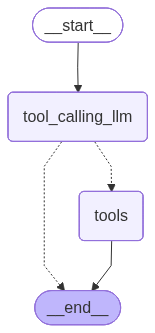

In [14]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [15]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================

It looks like you've provided an arXiv paper ID (1706.03762). To provide information about this paper, I will use the `arxiv` tool to fetch details.
Tool Calls:
  arxiv (482b518e-6544-41ba-a642-cc04a5e04615)
 Call ID: 482b518e-6544-41ba-a642-cc04a5e04615
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a 

In [16]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (c0536003-3e11-4339-a259-b7e359a541da)
 Call ID: c0536003-3e11-4339-a259-b7e359a541da
  Args:
    query: top 10 recent AI news March 3rd 2025
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Top 10 Daily AI News: March 3, 2025 Highlights - YouTube", "url": "https://www.youtube.com/watch?v=iWCZQO15usc", "content": "Catch the latest AI updates for March 1, 2025! From DeepSeek-R1's release to the Stargate Project announcement, here are today's top 10 AI", "score": 0.99993646}, {"title": "AI INTELLIGENCE | Weekly Top 10 (3/14/25) - Dwealth.news", "url": "https://dwealth.news/2025/03/ai-intelligence-weekly-top-10-3-14-25/", "content": "Dwealth.news Logo\nDwea

In [17]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (9c7b3913-72eb-4d68-855a-acc28528bf94)
 Call ID: 9c7b3913-72eb-4d68-855a-acc28528bf94
  Args:
    query: machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
ML fi
